# Create carbonate sensitivity beta

Overview: 
- `exp0`: $\beta(D), \eta(D)$, where $D$ is daily ROMS output <- **run**
- `exp1`: $\overline{\beta(D)}^\text{month}, \overline{\eta(D)}^\text{month}$, where $D$ is daily ROMS output <- **run**
- `exp2`: $\overline{\beta(D)}^\text{long-term-mean}, \overline{\eta(D)}^\text{long-term-mean}$, where $D$ is daily ROMS output <- **run**
- `exp3`: $\beta(D^\text{CESM}), \eta(D^\text{CESM})$, where $D^\text{CESM}$ is daily CESM output, regridded to ROMS grid <- **run**
- `exp4`: $\beta(\bar{D}^\text{month}), \eta(\bar{D}^\text{month})$, where $D$ is daily ROMS output
- `exp5`: $\beta(\bar{D}^\text{long-term-mean}), \eta(\bar{D}^\text{long-term-mean})$, where $D$ is daily ROMS output
- `exp6`: $\overline{\beta(D)}^\text{long-term-mean, spatial}, \overline{\beta(D)}^\text{long-term-mean, spatial}$, where $D$ is daily ROMS output <- **run**
- `exp7`: $\beta(\bar{D}^\text{long-term-mean, spatial}), \eta(\bar{D}^\text{long-term-mean, spatial})$, where $D$ is daily ROMS output
- `exp8`: $\beta(D^\text{Ocean-SODA}), \eta(D^\text{Ocean-SODA})$, where $D$ is monthly Ocean-SODA <- **run**
- `exp9`: $\beta(D^\text{Ocean-SODA}), \eta(D^\text{Ocean-SODA})$, where $D$ is 30-year Ocean-SODA climatology <- **run**


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import glob
import cftime
import datetime
from pathlib import Path
from sensitivities import (
    create_sensitivity_forcing,
    mid_month_days, build_constant, get_base_dir,
    lateral_fill_vars, regrid_to_roms, expand_climatology, save_per_year,
    SCRATCH_BASE,
)

In [2]:
import matplotlib.pyplot as plt

In [3]:
import xesmf

In [4]:
import os, socket

## `exp0`: $\beta(D), \eta(D)$

In [5]:
def create_input_exp0(year, buffer=None):

    _host = socket.gethostname()
    if "nersc" in _host or "perlmutter" in _host or os.path.exists("/global/cfs/projectdirs"):
        BASE_DIR = get_base_dir("dic")
    else:
        BASE_DIR = get_base_dir("alk")

    print(BASE_DIR)
    ds = xr.open_mfdataset(
        f"{BASE_DIR}/expCTRL/BETA/carbonate_sensitivity_{year}*.nc",
        concat_dim="time",
        combine="nested",
    )
    ds = ds.drop_vars(["time"]) # need to do this otherwise ROMS will get confused and take time as ddic_dco2 time variable (I think!)

    beta = ds.dDICdCO2.rename({"time": "itime"})
    eta  = ds.dDICdALK.rename({"time": "itime"})
    time = ds.ocean_time.rename({"time": "itime"}) / 86400 # convert to days

    return create_sensitivity_forcing(
        beta,
        eta,
        year=year,
        exp=0,
        buffer=buffer,
        time=time,
    )

In [6]:
ds = create_input_exp0(year=2000, buffer="left")

/anvil/projects/x-ees250129/x-nloose/DeficitTracer/experiments/pacific/roms_marbl_alk


In [7]:
ds = create_input_exp0(year=2001, buffer="right")

/anvil/projects/x-ees250129/x-nloose/DeficitTracer/experiments/pacific/roms_marbl_alk


## `exp1`: $\overline{\beta(D)}^\text{month}, \overline{\beta(D)}^\text{month}$

In [2]:
def create_input_exp1(ref="dic", year=2000, buffer=None):
    BASE_DIR = get_base_dir(ref)
    ds = xr.open_mfdataset(
        f"{BASE_DIR}/expCTRL/BETA/carbonate_sensitivity_{year}*.nc",
        concat_dim="time", combine="nested",
    )
    beta = ds.dDICdCO2.groupby("time.month").mean(dim="time").rename({"month": "itime"})
    eta  = ds.dDICdALK.groupby("time.month").mean(dim="time").rename({"month": "itime"})
    time = xr.DataArray(mid_month_days(year), dims="itime")
    return create_sensitivity_forcing(beta, eta, year=year, exp=1, buffer=buffer, time=time)

In [7]:
ds = create_input_exp1(ref="dic", year=2000, buffer="left")

In [9]:
ds = create_input_exp1(ref="dic", year=2001, buffer="right")

## `exp2`: $\overline{\beta(D)}^\text{long-term-mean}, \overline{\beta(D)}^\text{long-term-mean}$

In [2]:
def create_input_exp2(year, buffer=None):
    BASE_DIR = get_base_dir("dic")
    files = sorted(
        f for y in [2000, 2001] for f in Path(BASE_DIR).glob(f"expCTRL/BETA/carbonate_sensitivity_{y}*.nc")
    )
    ds = xr.open_mfdataset(files, concat_dim="time", combine="nested")
    beta = build_constant(ds.dDICdCO2.mean(dim="time").compute(), year)
    eta  = build_constant(ds.dDICdALK.mean(dim="time").compute(), year)
    return create_sensitivity_forcing(beta, eta, year=year, exp=2, buffer=buffer)

In [11]:
ds = create_input_exp2(year=2000, buffer="left")

In [5]:
ds = create_input_exp2(year=2001, buffer="right")

## `exp3`: $\beta(D^\text{CESM}), \eta(D^\text{CESM})$

### Data on original CESM grid

In [4]:
ds_cesm = xr.open_dataset("/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/carbonate-sensitivities/carbonate_sensitivity_daily.nc")

In [5]:
ds_cesm = ds_cesm.sel(
    time=slice(
        cftime.DatetimeNoLeap(347, 1, 1), # 1/1/1999
        cftime.DatetimeNoLeap(350, 12, 31) # 12/31/2002
    )
)

### Fill land values

In [6]:
ds_cesm = lateral_fill_vars(ds_cesm, spatial_dims=("nlat", "nlon"))

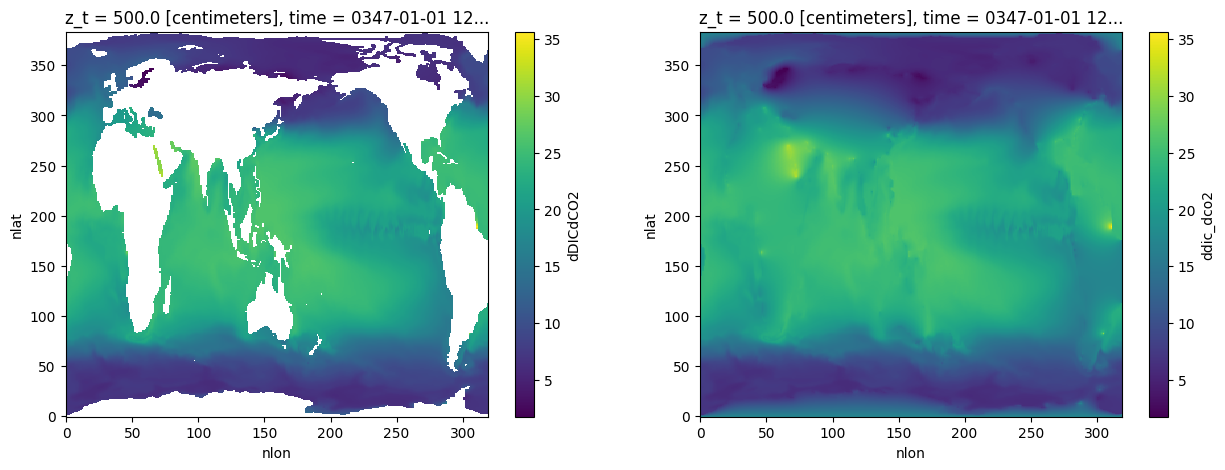

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_cesm["dDICdCO2"].isel(time=0).plot(ax=axs[0])
ds_cesm["ddic_dco2"].isel(time=0).plot(ax=axs[1])

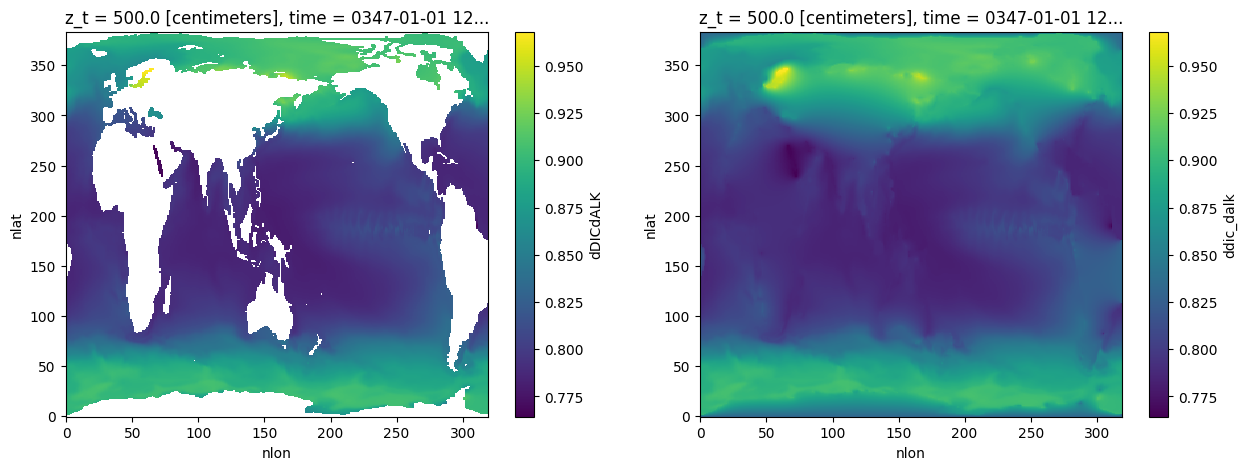

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_cesm["dDICdALK"].isel(time=0).plot(ax=axs[0])
ds_cesm["ddic_dalk"].isel(time=0).plot(ax=axs[1])

In [10]:
ds_cesm = ds_cesm.rename({'TLAT': 'lat', 'TLONG': 'lon'})

In [11]:
ds_cesm = ds_cesm.drop_vars(["dDICdCO2", "dDICdALK"])

### Target grid

In [12]:
ds_out = xr.open_dataset("../../INPUT/pacmed12_grd.nc")

In [13]:
ds_out = ds_out.rename({"lat_rho": "lat", "lon_rho": "lon"})

In [14]:
%time ds_regridded = regrid_to_roms(ds_cesm, ds_target=ds_out)

CPU times: user 50.1 s, sys: 6.07 s, total: 56.2 s
Wall time: 57.4 s


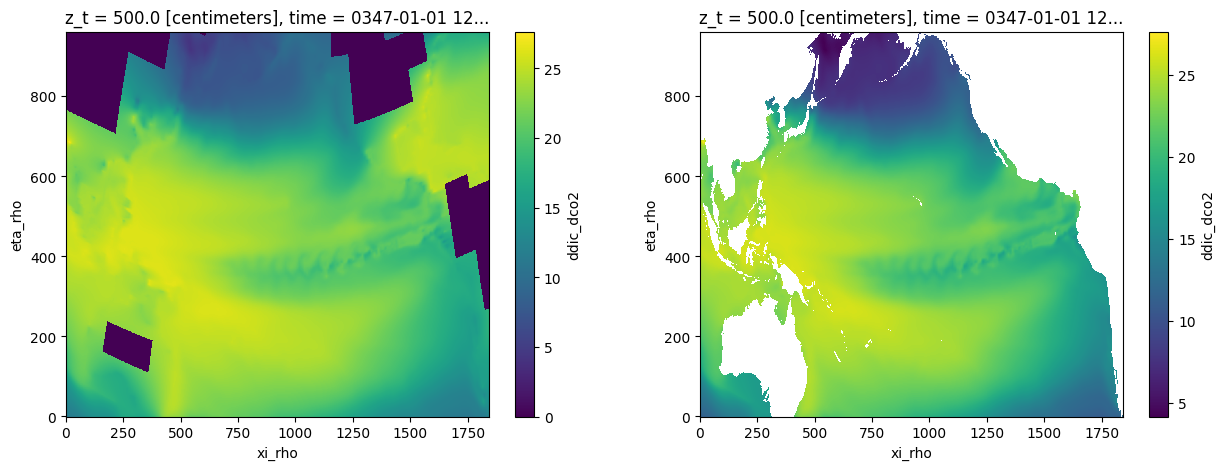

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_regridded.ddic_dco2.isel(time=0).plot(ax=axs[0])
ds_regridded.ddic_dco2.isel(time=0).where(ds_out.mask_rho).plot(ax=axs[1])

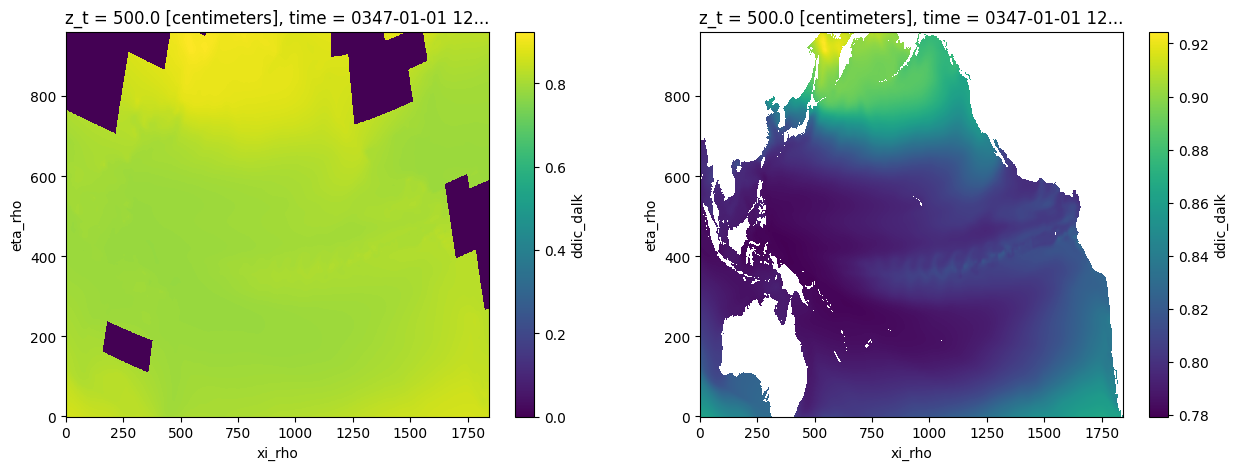

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_regridded.ddic_dalk.isel(time=0).plot(ax=axs[0])
ds_regridded.ddic_dalk.isel(time=0).where(ds_out.mask_rho).plot(ax=axs[1])

In [18]:
ds_regridded = ds_regridded.drop_vars("z_t")

In [19]:
ds_regridded

<xarray.Dataset> Size: 41GB
Dimensions:    (time: 1459, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time       (time) object 12kB 0347-01-01 12:00:00 ... 0350-12-30 12:00:00
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ddic_dco2  (time, eta_rho, xi_rho) float64 21GB 11.3 11.31 ... 16.48 16.49
    ddic_dalk  (time, eta_rho, xi_rho) float64 21GB 0.8637 0.8636 ... 0.8329
Attributes:
    regrid_method:  bilinear

In [20]:
# Convert CESM time (year 347 = year 1999) to real dates
year_offset = 1999 - 347
ds_regridded["time"] = [
    pd.Timestamp(year=t.year + year_offset, month=t.month, day=t.day, hour=t.hour)
    for t in ds_regridded.time.values
]

In [21]:
ds_regridded

<xarray.Dataset> Size: 41GB
Dimensions:    (time: 1459, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time       (time) datetime64[ns] 12kB 1999-01-01T12:00:00 ... 2002-12-30T...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ddic_dco2  (time, eta_rho, xi_rho) float64 21GB 11.3 11.31 ... 16.48 16.49
    ddic_dalk  (time, eta_rho, xi_rho) float64 21GB 0.8637 0.8636 ... 0.8329
Attributes:
    regrid_method:  bilinear

In [ ]:
save_per_year(ds_regridded, exp=3, years=[1999, 2000, 2001, 2002])

## `exp4`: $\beta(\bar{D}^\text{month}), \eta(\bar{D}^\text{month})$

In [64]:
def create_input_exp4(ref="dic", year=2000, buffer=None):
    base_dir = get_base_dir(ref)
    ds = xr.open_mfdataset(
        f"{base_dir}/expCTRL/BETA/carbonate_sensitivity_from_monthly_data_{year}*.nc",
        concat_dim="time", combine="nested",
    )
    beta = ds.dDICdCO2.rename({"time": "itime"})
    eta  = ds.dDICdALK.rename({"time": "itime"})
    time = xr.DataArray(mid_month_days(year), dims="itime")
    return create_sensitivity_forcing(beta, eta, year=year, exp=4, buffer=buffer, time=time)

In [65]:
ds = create_input_exp4(ref="dic", year=2000, buffer="left")

In [72]:
ds = create_input_exp4(ref="dic", year=2001, buffer="right")

## `exp5`: $\beta(\bar{D}^\text{long-term-mean}), \eta(\bar{D}^\text{long-term-mean})$

In [73]:
def create_input_exp5(ref="dic", year=2000, buffer=None):
    base_dir = get_base_dir(ref)
    ds = xr.open_dataset(f"{base_dir}/expCTRL/BETA/carbonate_sensitivity_from_mean_data.nc")
    beta = build_constant(ds.dDICdCO2, year)
    eta  = build_constant(ds.dDICdALK, year)
    return create_sensitivity_forcing(beta, eta, year=year, exp=5, buffer=buffer)

In [74]:
ds = create_input_exp5(ref="dic", year=2000, buffer="left")

In [82]:
ds = create_input_exp5(ref="dic", year=2001, buffer="right")

## `exp6`: $\overline{\beta(D)}^\text{long-term-mean, spatial}, \overline{\beta(D)}^\text{long-term-mean, spatial}$

In [50]:
def create_input_exp6(ref="dic", year=2000, buffer=None):
    base_dir = get_base_dir(ref)
    files = sorted(
        f for y in [2000, 2001]
        for f in Path(base_dir).glob(f"expCTRL/BETA/carbonate_sensitivity_{y}*.nc")
    )
    ds = xr.open_mfdataset(files, concat_dim="time", combine="nested")
    beta = build_constant(ds.dDICdCO2.mean().compute() * xr.ones_like(ds.dDICdCO2.isel(time=0)), year)
    eta  = build_constant(ds.dDICdALK.mean().compute() * xr.ones_like(ds.dDICdALK.isel(time=0)), year)
    return create_sensitivity_forcing(beta, eta, year=year, exp=6, buffer=buffer)

In [51]:
ds = create_input_exp6(year=2000, buffer="left")

In [52]:
ds

<xarray.Dataset> Size: 10GB
Dimensions:         (itime: 367, eta_rho: 962, xi_rho: 1842)
Dimensions without coordinates: itime, eta_rho, xi_rho
Data variables:
    ddic_dco2       (itime, eta_rho, xi_rho) float64 5GB 18.67 18.67 ... 18.67
    ddic_dalk       (itime, eta_rho, xi_rho) float64 5GB 0.8181 ... 0.8181
    ddic_dco2_time  (itime) float64 3kB 1.726e+03 1.826e+03 ... 2.191e+03

In [53]:
ds = create_input_exp6(year=2001, buffer="right")

## `exp7`: $\beta(\bar{D}^\text{long-term-mean, spatial}), \eta(\bar{D}^\text{long-term-mean, spatial})$

In [54]:
base_path = "/pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/roms/"

In [55]:
def create_input_exp7(ref="dic", year=2000, buffer=None):
    base_dir = get_base_dir(ref)
    ds = xr.open_dataset(f"{base_dir}/expCTRL/BETA/carbonate_sensitivity_from_spatial_and_temporal_mean_data.nc")
    ds_grid = xr.open_dataset(f"{base_dir}/expCTRL/pacmed12_grd.nc")
    beta = build_constant(ds.dDICdCO2.values * xr.ones_like(ds_grid.mask_rho), year)
    eta  = build_constant(ds.dDICdALK.values * xr.ones_like(ds_grid.mask_rho), year)
    return create_sensitivity_forcing(beta, eta, year=year, exp=7, buffer=buffer)

In [56]:
ds = create_input_exp7(ref="dic", year=2000, buffer="left")

In [57]:
ds

<xarray.Dataset> Size: 10GB
Dimensions:         (itime: 367, eta_rho: 962, xi_rho: 1842)
Dimensions without coordinates: itime, eta_rho, xi_rho
Data variables:
    ddic_dco2       (itime, eta_rho, xi_rho) float64 5GB 18.58 18.58 ... 18.58
    ddic_dalk       (itime, eta_rho, xi_rho) float64 5GB 0.8176 ... 0.8176
    ddic_dco2_time  (itime) float64 3kB 1.726e+03 1.826e+03 ... 2.191e+03

In [60]:
ds = create_input_exp7(ref="dic", year=2001, buffer="right")

## `exp8`: $\beta(D^\text{Ocean-SODA}), \eta(D^\text{Ocean-SODA})$

In [22]:
ds_soda = xr.open_dataset("/global/cfs/projectdirs/m4746/Users/nora/Datasets/OceanSODA/OceanSODA_carbonate_sensitivity.nc")

In [23]:
ds_soda.time

<xarray.DataArray 'time' (time: 360)> Size: 3kB
array(['1993-01-15T00:00:00.000000000', '1993-02-15T00:00:00.000000000',
       '1993-03-15T00:00:00.000000000', ..., '2022-10-15T00:00:00.000000000',
       '2022-11-15T00:00:00.000000000', '2022-12-15T00:00:00.000000000'],
      shape=(360,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2022-12-15

In [24]:
ds_soda = ds_soda.sel(
    time=slice(
        datetime.datetime(1999, 12, 15),
        datetime.datetime(2002, 2, 15)
    )
)

In [25]:
ds_soda

<xarray.Dataset> Size: 28MB
Dimensions:   (time: 27, lat: 180, lon: 360)
Coordinates:
  * time      (time) datetime64[ns] 216B 1999-12-15 2000-01-15 ... 2002-02-15
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    dDICdCO2  (time, lat, lon) float64 14MB ...
    dDICdALK  (time, lat, lon) float64 14MB ...

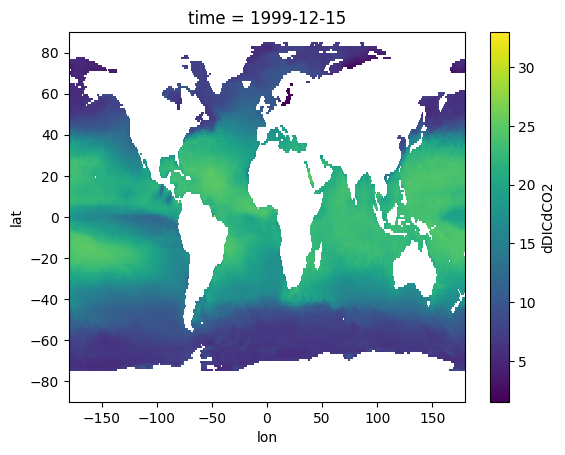

In [26]:
ds_soda.dDICdCO2.isel(time=0).plot()

### Fill land values

In [27]:
ds_soda = lateral_fill_vars(ds_soda, spatial_dims=("lat", "lon"), iter_dim="time")

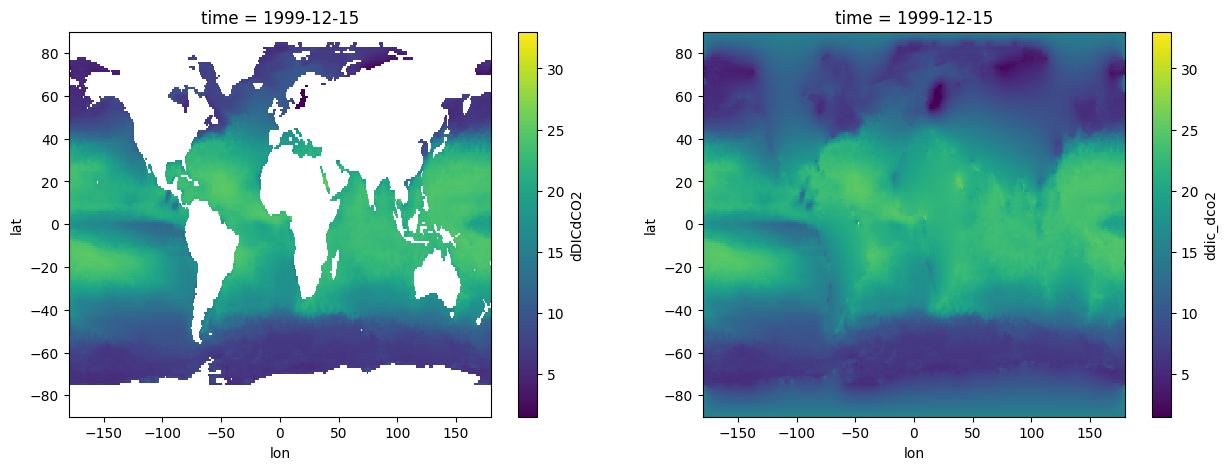

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_soda["dDICdCO2"].isel(time=0).plot(ax=axs[0])
ds_soda["ddic_dco2"].isel(time=0).plot(ax=axs[1])

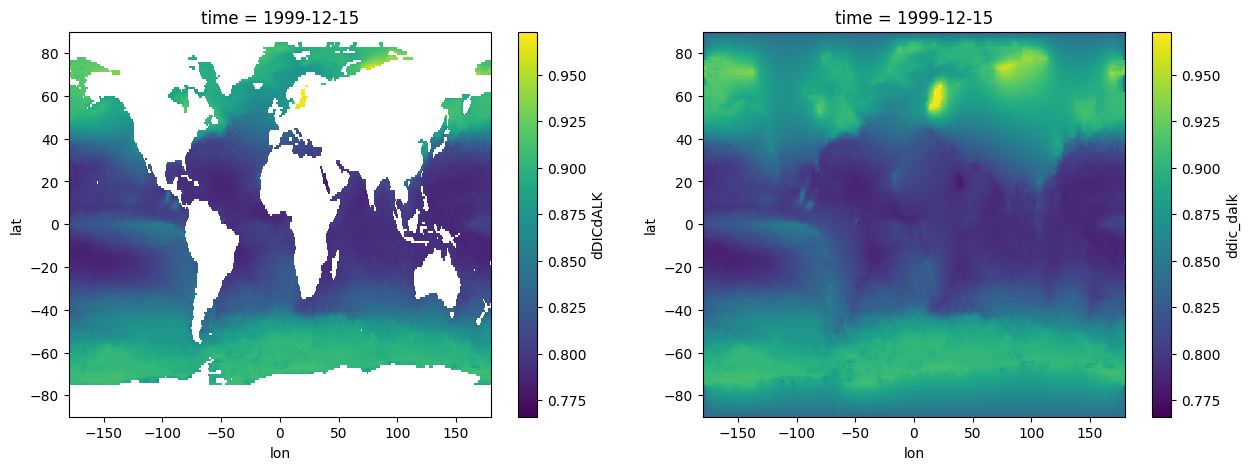

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_soda["dDICdALK"].isel(time=0).plot(ax=axs[0])
ds_soda["ddic_dalk"].isel(time=0).plot(ax=axs[1])

In [30]:
ds_soda = ds_soda.drop_vars(["dDICdCO2", "dDICdALK"])

In [31]:
%time ds_regridded = regrid_to_roms(ds_soda)

CPU times: user 19.8 s, sys: 752 ms, total: 20.5 s
Wall time: 20.5 s


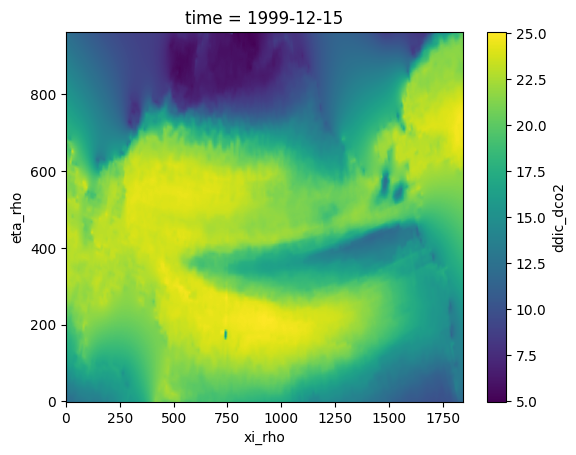

In [32]:
ds_regridded.ddic_dco2.isel(time=0).plot()

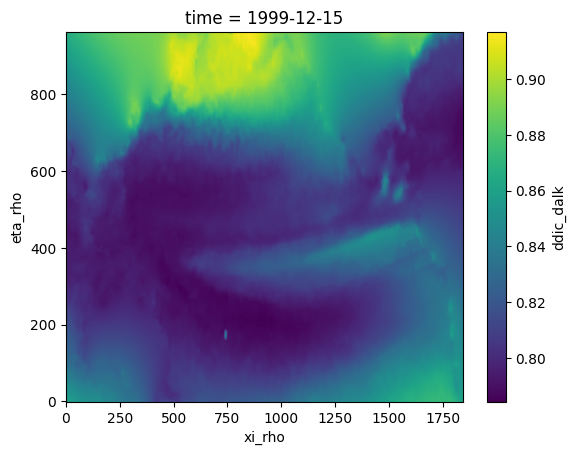

In [33]:
ds_regridded.ddic_dalk.isel(time=0).plot()

In [34]:
ds_regridded

<xarray.Dataset> Size: 766MB
Dimensions:    (time: 27, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time       (time) datetime64[ns] 216B 1999-12-15 2000-01-15 ... 2002-02-15
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ddic_dco2  (time, eta_rho, xi_rho) float64 383MB 11.49 11.55 ... 16.78 16.8
    ddic_dalk  (time, eta_rho, xi_rho) float64 383MB 0.8624 0.862 ... 0.8291
Attributes:
    regrid_method:  bilinear

In [35]:
save_per_year(ds_regridded, exp=8, years=[1999, 2000, 2001, 2002])

## `exp9`: $\beta(D^\text{Ocean-SODA}), \eta(D^\text{Ocean-SODA})$

In [4]:
ds_soda = xr.open_dataset("/global/cfs/projectdirs/m4746/Users/nora/Datasets/OceanSODA/OceanSODA_carbonate_sensitivity.nc")

In [5]:
ds_soda.time

<xarray.DataArray 'time' (time: 360)> Size: 3kB
array(['1993-01-15T00:00:00.000000000', '1993-02-15T00:00:00.000000000',
       '1993-03-15T00:00:00.000000000', ..., '2022-10-15T00:00:00.000000000',
       '2022-11-15T00:00:00.000000000', '2022-12-15T00:00:00.000000000'],
      shape=(360,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2022-12-15

In [6]:
ds_soda_clim = ds_soda.groupby("time.month").mean()

In [7]:
ds_soda_clim

<xarray.Dataset> Size: 12MB
Dimensions:   (month: 12, lat: 180, lon: 360)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    dDICdCO2  (month, lat, lon) float64 6MB nan nan nan nan ... nan nan nan nan
    dDICdALK  (month, lat, lon) float64 6MB nan nan nan nan ... nan nan nan nan

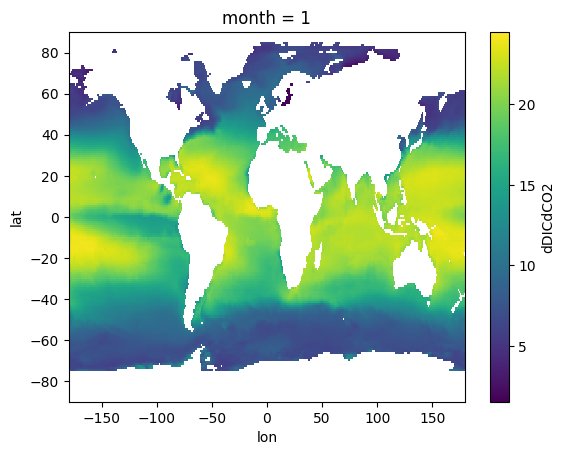

In [8]:
ds_soda_clim.dDICdCO2.isel(month=0).plot()

### Fill land values

In [9]:
ds_soda_clim = lateral_fill_vars(ds_soda_clim, spatial_dims=("lat", "lon"), iter_dim="month")

In [10]:
ds_soda_clim

<xarray.Dataset> Size: 25MB
Dimensions:    (month: 12, lat: 180, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    dDICdCO2   (month, lat, lon) float64 6MB nan nan nan nan ... nan nan nan nan
    dDICdALK   (month, lat, lon) float64 6MB nan nan nan nan ... nan nan nan nan
    ddic_dco2  (month, lat, lon) float64 6MB 14.94 14.94 14.94 ... 14.73 14.73
    ddic_dalk  (month, lat, lon) float64 6MB 0.8424 0.8424 ... 0.8439 0.8439

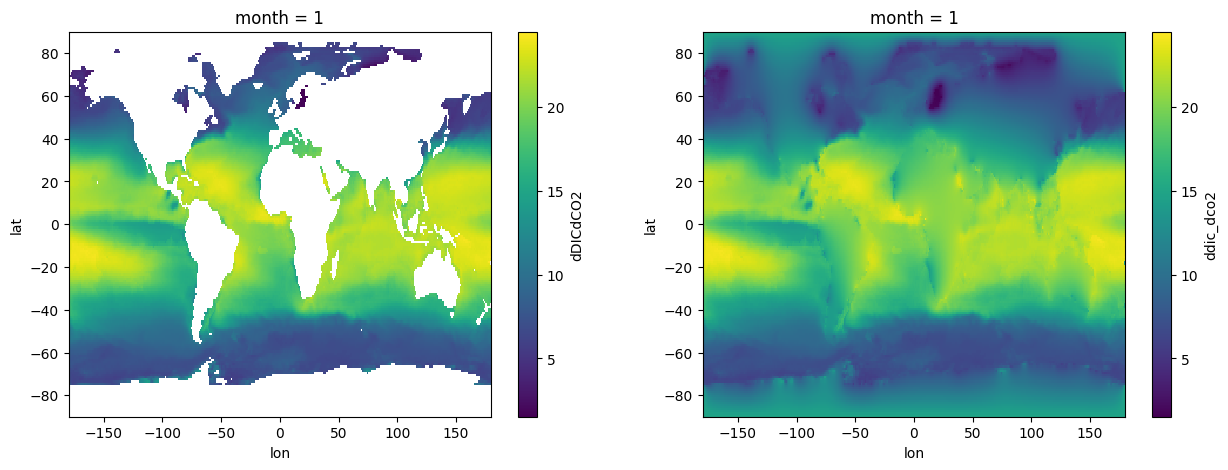

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_soda_clim["dDICdCO2"].isel(month=0).plot(ax=axs[0])
ds_soda_clim["ddic_dco2"].isel(month=0).plot(ax=axs[1])

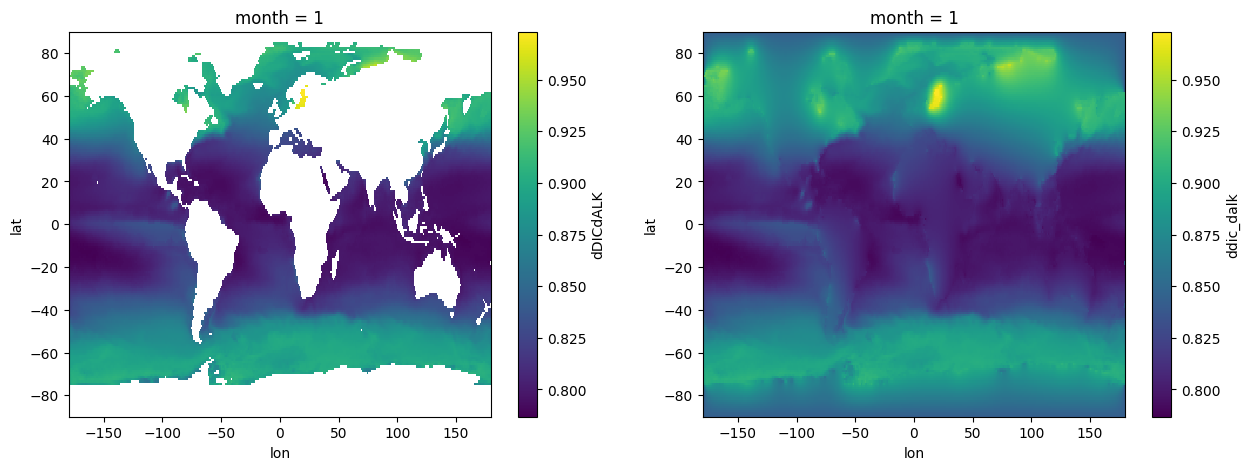

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ds_soda_clim["dDICdALK"].isel(month=0).plot(ax=axs[0])
ds_soda_clim["ddic_dalk"].isel(month=0).plot(ax=axs[1])

In [15]:
ds_soda_clim = ds_soda_clim.drop_vars(["dDICdCO2", "dDICdALK"])

In [16]:
%time ds_regridded = regrid_to_roms(ds_soda_clim)

CPU times: user 20.2 s, sys: 1.35 s, total: 21.5 s
Wall time: 23.1 s


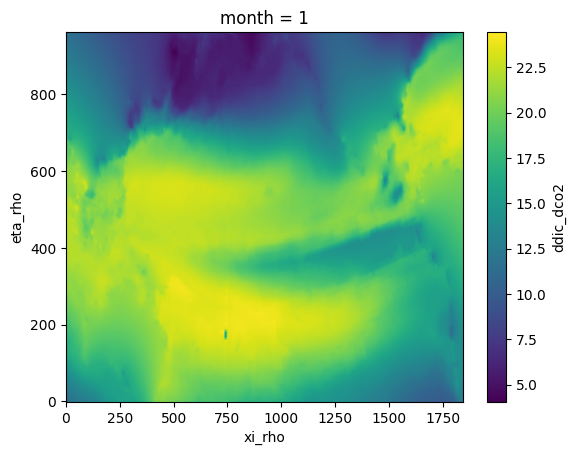

In [17]:
ds_regridded.ddic_dco2.isel(month=0).plot()

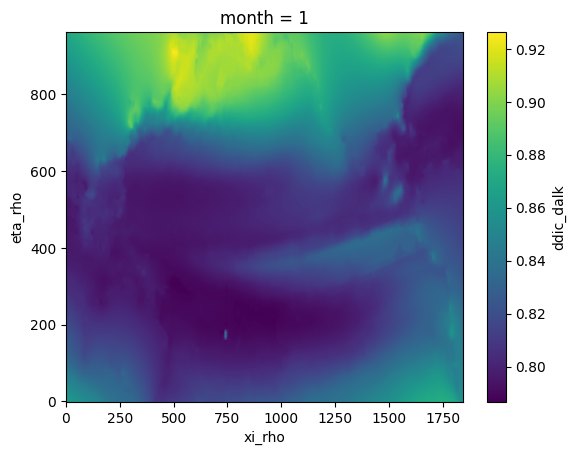

In [18]:
ds_regridded.ddic_dalk.isel(month=0).plot()

In [19]:
ds_regridded

<xarray.Dataset> Size: 340MB
Dimensions:    (month: 12, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ddic_dco2  (month, eta_rho, xi_rho) float64 170MB 11.12 11.17 ... 18.2 18.23
    ddic_dalk  (month, eta_rho, xi_rho) float64 170MB 0.8644 0.8641 ... 0.8211
Attributes:
    regrid_method:  bilinear

In [20]:
ds_expanded = expand_climatology(ds_regridded, years=[1999, 2000, 2001, 2002])

In [21]:
ds_expanded

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 48, eta_rho: 962, xi_rho: 1842)
Coordinates:
    month      (time) int64 384B 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * time       (time) datetime64[ns] 384B 1999-01-16T12:00:00 ... 2002-12-16T...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ddic_dco2  (time, eta_rho, xi_rho) float64 680MB 11.12 11.17 ... 18.2 18.23
    ddic_dalk  (time, eta_rho, xi_rho) float64 680MB 0.8644 0.8641 ... 0.8211
Attributes:
    regrid_method:  bilinear

In [22]:
save_per_year(ds_expanded, exp=9, years=[1999, 2000, 2001, 2002])